In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def _resolve_csv_path():
    """Find predictions_d1.csv in common locations for notebooks and scripts."""
    # In notebooks, __file__ is usually undefined; fall back to current working directory.
    if "__file__" in globals():
        base_dir = os.path.dirname(os.path.abspath(__file__))
    else:
        base_dir = os.getcwd()

    candidates = [
        os.path.join(base_dir, "results", "predictions_d1.csv"),
        os.path.join(os.getcwd(), "results", "predictions_d1.csv"),
        os.path.join(base_dir, "Deep_Galerkin_01", "results", "predictions_d1.csv"),
    ]
    for path in candidates:
        if os.path.isfile(path):
            return path
    raise FileNotFoundError(
        "Could not find results/predictions_d1.csv. "
        "Checked notebook/script folder and current working directory."
    )

Saved figure to d:\Dropbox\NTU_studies\Modules\Nonlinear_Wave\Reading\Nonlinear_Wave_Polynomial_Github\Nonlinear_Wave_simulations\Deep_Galerkin_01\results\predictions_d1_plot.png


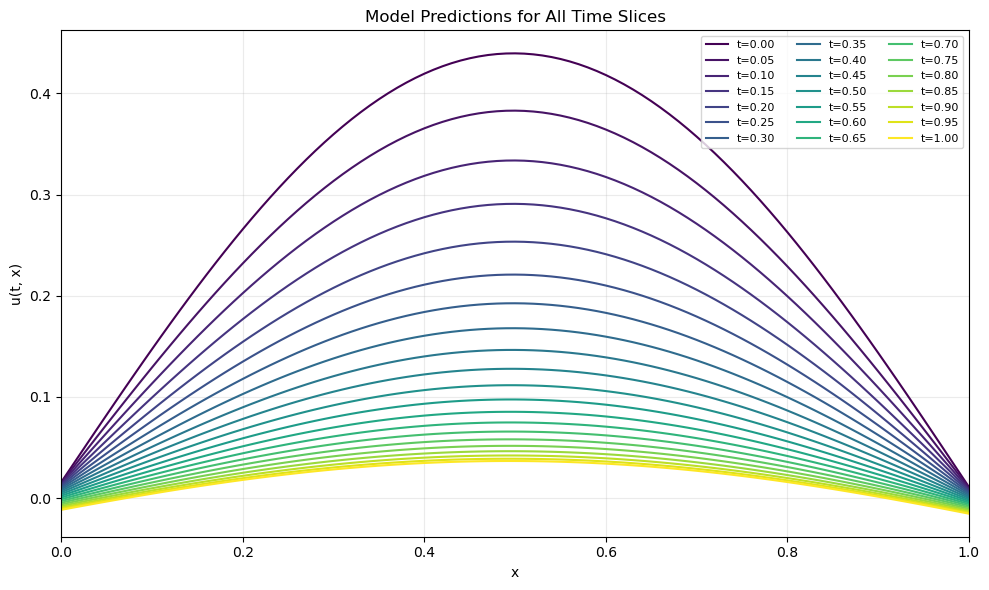

In [3]:
csv_path = _resolve_csv_path()

# Header stores x values (e.g., 0.00,0.01,...,1.00); data rows are time slices.
x_values = np.genfromtxt(csv_path, delimiter=",", max_rows=1)
predictions = np.loadtxt(csv_path, delimiter=",", skiprows=1)

if predictions.ndim == 1:
    predictions = predictions.reshape(1, -1)

# Reconstruct t axis from row count; generation code uses dt=0.05 from 0 to 1.
t_values = np.linspace(0.0, 1.0, predictions.shape[0])

# Plot every row (each t value) as a separate line against x columns.
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(t_values)))
for row_idx, t_val in enumerate(t_values):
    plt.plot(x_values, predictions[row_idx, :], color=colors[row_idx], label=f"t={t_val:.2f}")

plt.title("Model Predictions for All Time Slices")
plt.xlabel("x")
plt.ylabel("u(t, x)")
plt.xlim(0.0, 1.0)
plt.grid(alpha=0.25)
plt.legend(ncol=3, fontsize=8)

# Save the plotted figure under the same results/ folder as the CSV.
results_dir = os.path.dirname(csv_path)
figure_path = os.path.join(results_dir, "predictions_d1_plot.png")
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to {figure_path}")

plt.tight_layout()
plt.show()